# Hackathon Notebook

**Exploring the Netflix Dataset**:

Netflix is one of the world's largest streaming platforms, with millions of users streaming movies and TV shows every day. As a result, Netflix has accumulated a massive amount of data that can be used to gain insights into user behaviour, preferences, and more. In this project, students will explore a dataset containing information about movies and TV shows available on Netflix.

**Brief**:
The CEO of CS-Streaming has brought you and your team in to analyse Netflix data for their new streaming service. They are confident that your analysis will be helpful to you in making decisions about their service. They need your expertise to uncover trends and insights from the Netflix data that will be beneficial to their new product. They are eager to begin this project and will therefore need a timely response.

You are to report on how CS-Streaming can best optimise its services and compete with Netflix.



---

**About the Dataset**:

This tabular dataset encompasses a comprehensive listing of all the movies and TV shows available on
Netflix, providing intricate details such as cast, directors, ratings, release year, duration, and more.


**Key Columns in the Dataset:**
1. **show_id**: An exclusive identifier for each show on Netflix.
2. **type**: Indicates whether the entry is a "Movie" or a "TV Show."
3. **title**: The name of the movie or TV show.
4. **director**: The director(s) responsible for the movie or TV show.
5. **cast**: The principal cast or actors featured in the movie or TV show.
6. **country**: The country or countries where the movie or TV show was produced.
7. **date_added**: The date when the movie or TV show was added to the Netflix catalogue.
8. **release_year**: The original release year of the movie or TV show.
9. **rating**: The content rating assigned to the movie or TV show (e.g., PG, TV-MA, etc.).
10. **duration**: For movies, the duration is in minutes; for TV shows, the number of seasons.
11. **listed_in**: The genre(s) or category(ies) classifying the movie or TV show.
12. **description**: A concise summary of the movie or TV show.

---
[Link Data Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows)

---

**Objective**

***This is my contribution to the hackathon presentation created together with the team.***

The objective is to leverage actor trends and insights from Netflix's dataset to help CS-Streaming optimize its content strategy, better address audiences in various regions, and become more competitive in the streaming market.

**My analysis focuses on:**

1. Identifying the most frequent actors in Netflix movies and TV shows.
2. Discovering the most popular actors in the United States and the United Kingdom.




### Step 1: Importing Necessary Libraries

In [1]:
import pandas as pd                      # pandas: data manipulation and analysis
import matplotlib.pyplot as plt          # matplotlib.pyplot: for creating visualizations
import seaborn as sns                    # # seaborn: for statistical data visualization

### Step 2: Loading and Inspecting the Data

In [2]:
#loading the Netflix data

netflix = pd.read_csv('data/netflix_titles.csv')

In [3]:
#inspect the first five rows of the dataset

netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# display a summary of the Netflix data, including data types, non-null counts, and memory usage

netflix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
# get the number of rows and columns in the Netflix data

netflix.shape

(8807, 12)

In [6]:
netflix.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

### Step 3: Data Cleaning

Before making any changes to the original data, I will create a copy of it the Netflix dataset . This ensures I can always revert back to the original if needed.

**3.1 Make copy of data**

In [7]:
# copying data to maintain the original dataset
netflix_copy1 = netflix.copy()

**3.2 Convert Data Types:**

In [8]:
# ensuring that the ' date_added' column is in datetime format

netflix_copy1['date_added'] = pd.to_datetime(netflix_copy1['date_added'], format = 'mixed')

In [9]:
# ensuring that the ' release_year' column is in the correct numeric format.

netflix_copy1['release_year'].dtype

dtype('int64')

We can see that the column 'release_year' has a data type of int64, that means it is numeric.

In [10]:
netflix_copy1.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [11]:
#check 
netflix_copy1.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


**3.3 Handle Missing Values:**

_for numeric columns, fill in missing values with the mean or median. · For categorical columns 'rating', 'duration' and 'country', fill missing values with the mode or a placeholder like "Unknown", “Not Rated”_

In [12]:
netflix_copy1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [13]:
#categorical columns fill missing values:
#'rating' - 'Not Rated'
#'duration', 'country', 'director' and 'cast' - 'Unknown'


netflix_copy1['rating'] = netflix_copy1['rating'].fillna('Not Rated')
netflix_copy1['duration'] = netflix_copy1['duration'].fillna('Unknown')
netflix_copy1['country'] = netflix_copy1['country'].fillna('Unknown')
netflix_copy1['director'] = netflix_copy1['director'].fillna('Unknown')
netflix_copy1['cast'] = netflix_copy1['cast'].fillna('Unknown')


In [14]:
netflix_copy1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 825.8+ KB


In [15]:
most_frequent_date = netflix_copy1['date_added'].mode()[0]
most_frequent_date

Timestamp('2020-01-01 00:00:00')

In [16]:
netflix_copy1.fillna({'date_added':most_frequent_date}, inplace=True)

**3.4 Create Additional Features:**

In [17]:
# extrating the month and year 

netflix_copy1['month'] = netflix_copy1['date_added'].dt.month.astype(int)
netflix_copy1['year'] = netflix_copy1['date_added'].dt.year.astype(int)

In [18]:
numeric_cols = netflix_copy1[['release_year','month','year']].describe()
numeric_cols

,release_year,month,year
count,8807.000000,8807.000000,8807.000000
mean,2014.180198,6.648575,2018.873169
std,8.819312,3.439879,1.573808
min,1925.000000,1.000000,2008.000000
25%,2013.000000,4.000000,2018.000000
50%,2017.000000,7.000000,2019.000000
75%,2019.000000,10.000000,2020.000000
max,2021.000000,12.000000,2021.000000


In [19]:
missing_values_count = netflix_copy1[['release_year','month','year']].isnull().sum()
missing_values_count

release_year    0
month           0
year            0
dtype: int64

_Standardize capitalization in categorical columns 'type' and 'rating' for consistency._

In [20]:
netflix_copy1['type'] = netflix_copy1['type'].str.title() #first letter capitalized in each word
netflix_copy1['rating'] = netflix_copy1['rating'].str.upper() # the same as original

In [21]:
# check the first few rows of the updated columns

netflix_copy1[['type','rating']].head()

,type,rating
0,Movie,PG-13
1,Tv Show,TV-MA
2,Tv Show,TV-MA
3,Tv Show,TV-MA
4,Tv Show,TV-MA


In [22]:
# changing 'listed_in' to 'category' for better readability
netflix_copy1.rename(columns={'listed_in': 'category'}, inplace=True)

**3.5 Remove Duplicates:**

In [23]:
#drop duplicates
netflix_copy1 = netflix_copy1.drop_duplicates()

In [24]:
#check again if there are missing values in dataset
netflix_copy1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      8807 non-null   object        
 4   cast          8807 non-null   object        
 5   country       8807 non-null   object        
 6   date_added    8807 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8807 non-null   object        
 9   duration      8807 non-null   object        
 10  category      8807 non-null   object        
 11  description   8807 non-null   object        
 12  month         8807 non-null   int64         
 13  year          8807 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(10)
memory usage: 963.4+ KB


In [25]:
netflix_copy1.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,category,description,month,year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",9,2021
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",9,2021
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,9,2021
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",9,2021
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,9,2021


### Step 4: Analysis and visualisation


In [26]:
type_counts = netflix_copy1['type'].value_counts()
type_counts

type
Movie      6131
Tv Show    2676
Name: count, dtype: int64

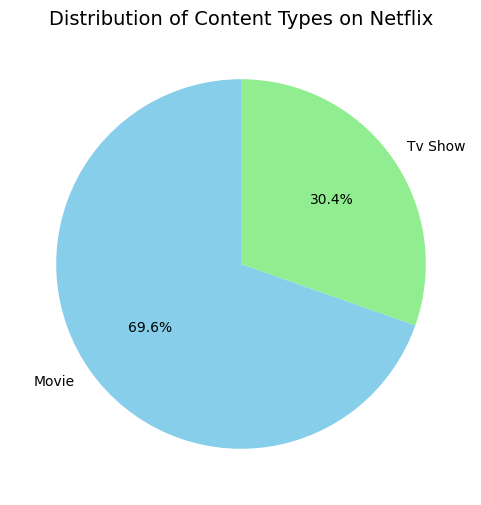

In [27]:
plt.figure(figsize=(6, 6))
type_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen'])
plt.title('Distribution of Content Types on Netflix', fontsize=14)
plt.ylabel('')  
plt.show()

In [28]:
#separate movies and Tv Shows
movies = netflix_copy1[netflix_copy1['type'] == 'Movie']
tv_show = netflix_copy1[netflix_copy1['type'] == 'Tv Show']

**Q1. Who are the most frequent actors in movies and Tv shows?**

In [29]:
#count the most frequent actors
movie_actor_counts = movies['cast'].str.split(', ').explode().str.strip().value_counts()
tv_show_actor_counts = tv_show['cast'].str.split(', ').explode().str.strip().value_counts()

In [30]:
# exclude 'unkwnown'
movie_actor_unknown = movie_actor_counts[movie_actor_counts.index != 'Unknown']
tv_show_actor_unknown = tv_show_actor_counts[tv_show_actor_counts.index != 'Unknown']

In [31]:
# top 5 movies actors
movie_actor_unknown.head(5)

cast
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    32
Om Puri             30
Akshay Kumar        30
Name: count, dtype: int64

In [32]:
top_movie_actors = movie_actor_unknown.head()

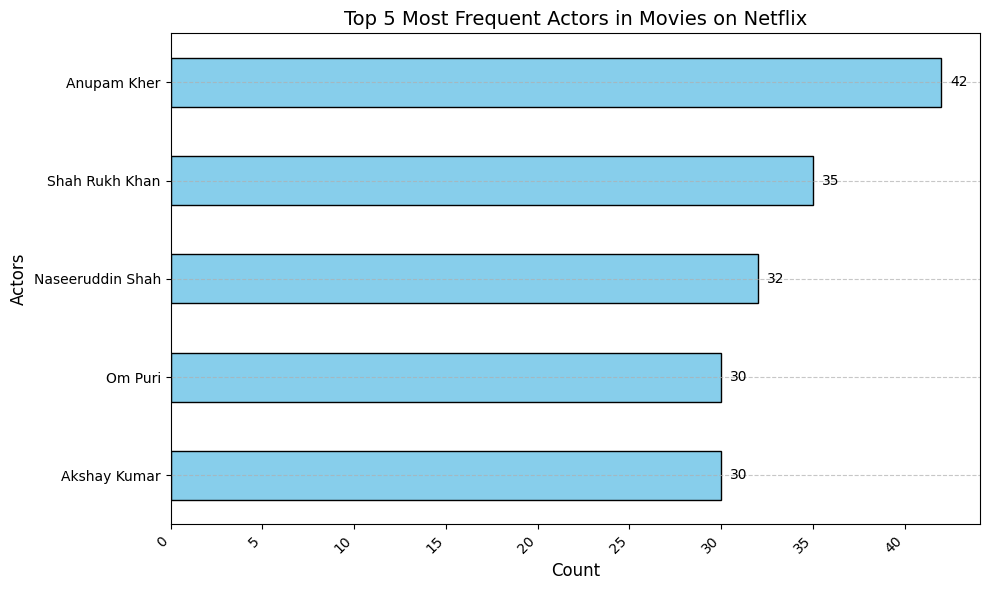

In [33]:
# visulalization for top 5 actors in movies

plt.figure(figsize=(10, 6))
top_movie_actors.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Top 5 Most Frequent Actors in Movies on Netflix', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Actors', fontsize=12)

for index, value in enumerate(top_movie_actors.values):
    plt.text(value + 0.5, index, str(value), va='center', fontsize=10)
    
plt.gca().invert_yaxis()
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()


In [34]:
tv_show_actor_unknown.head()

cast
Takahiro Sakurai    25
Yuki Kaji           19
Daisuke Ono         17
Junichi Suwabe      17
Ai Kayano           17
Name: count, dtype: int64

In [35]:
top_tv_show_actors = tv_show_actor_unknown.head()

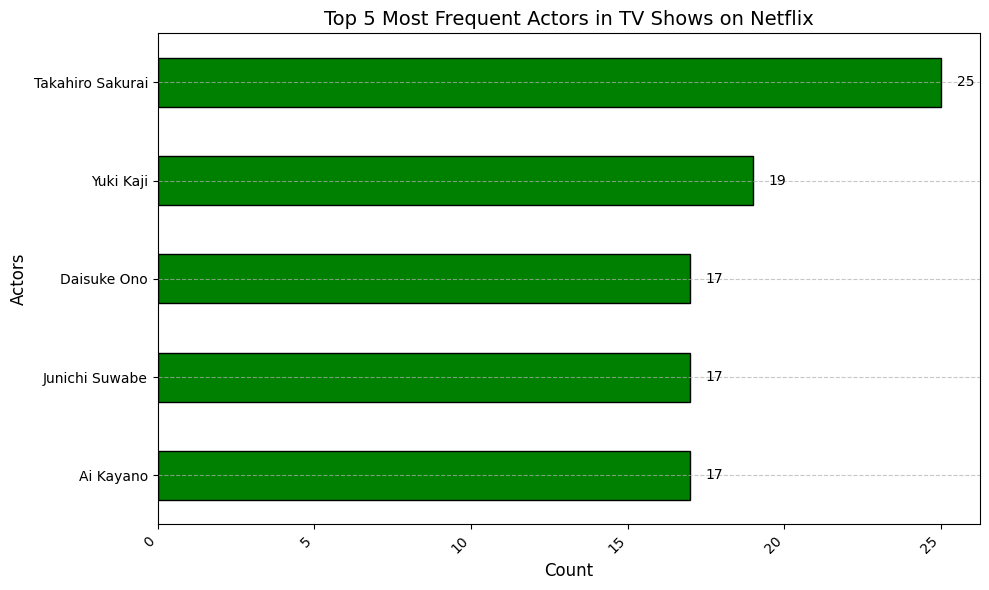

In [36]:
plt.figure(figsize=(10, 6))
top_tv_show_actors.plot(kind='barh', color='green', edgecolor='black')
plt.title('Top 5 Most Frequent Actors in TV Shows on Netflix', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Actors', fontsize=12)

for index, value in enumerate(top_tv_show_actors.values):
    plt.text(value + 0.5, index, str(value), va='center', fontsize=10)
    
plt.xticks(rotation=45, ha='right')
plt.gca().invert_yaxis()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Q2. Which actors dominate Netflix content in the US and UK?**

In [37]:
us_actors = netflix_copy1[netflix_copy1['country'] == 'United States']
uk_actors = netflix_copy1[netflix_copy1['country'] == 'United Kingdom']

In [38]:
us_actor_counts = us_actors['cast'].str.split(', ').explode().str.strip().value_counts()
us_actor_unknown = us_actor_counts[us_actor_counts.index != 'Unknown']

In [39]:
top_us_actors = us_actor_unknown.head()

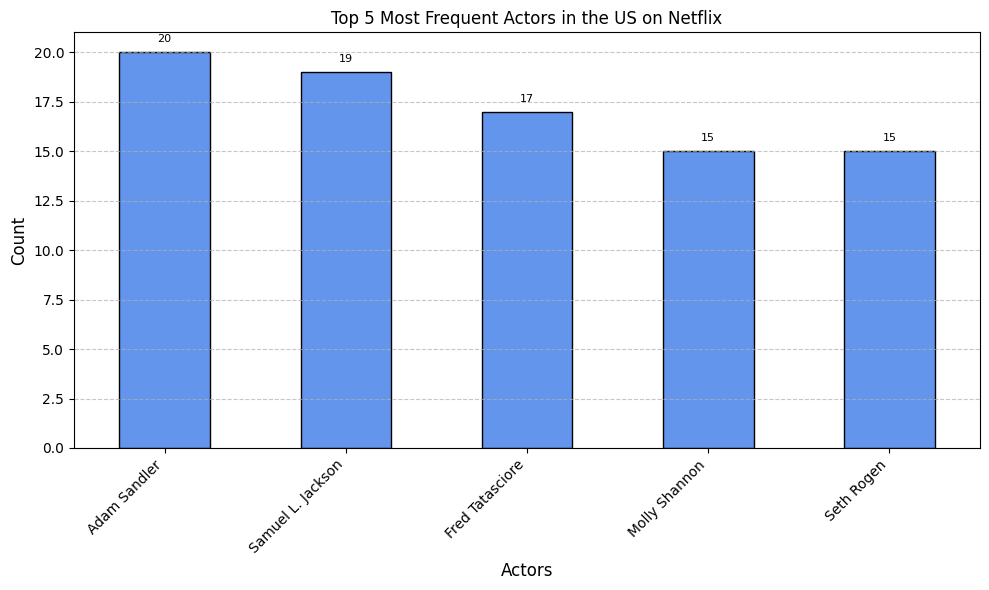

In [40]:
plt.figure(figsize=(10, 6))
top_us_actors.plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Top 5 Most Frequent Actors in the US on Netflix', fontsize=12)
plt.xlabel('Actors', fontsize=12)
plt.ylabel('Count', fontsize=12)

for index, value in enumerate(top_us_actors.values):
    plt.text(index, value + 0.5, str(value), ha='center', fontsize=8)

    
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [41]:
uk_actor_counts = uk_actors['cast'].str.split(', ').explode().str.strip().value_counts()
uk_actor_unknown = uk_actor_counts[uk_actor_counts.index != 'Unknown']

In [42]:
top_uk_actors = uk_actor_unknown.head()
top_uk_actors

cast
Michael Palin    10
Terry Jones      10
Terry Gilliam    10
Eric Idle        10
John Cleese      10
Name: count, dtype: int64

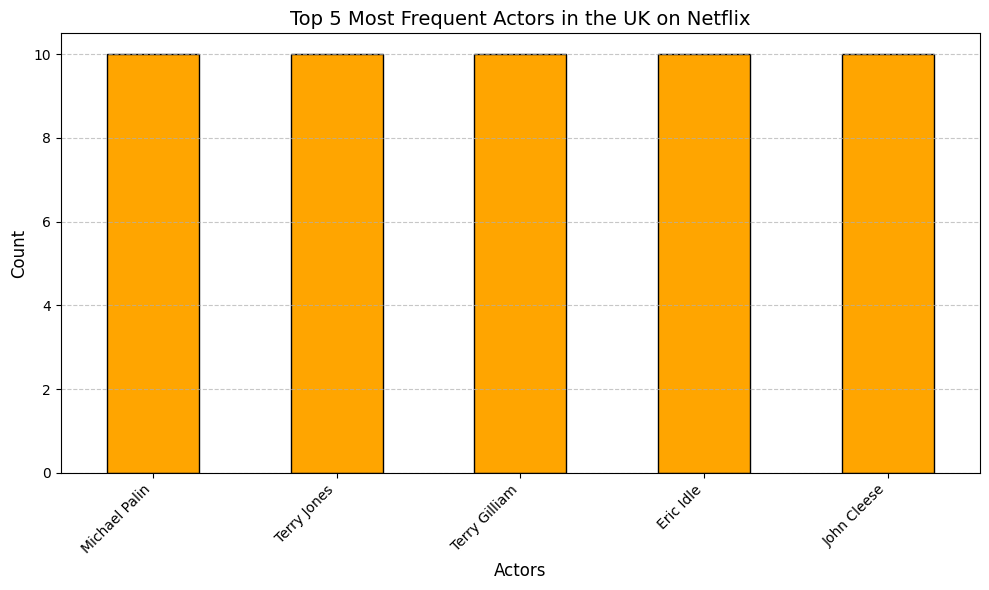

In [43]:
plt.figure(figsize=(10, 6))
top_uk_actors.plot(kind='bar', color='orange', edgecolor='black')
plt.title('Top 5 Most Frequent Actors in the UK on Netflix', fontsize=14)
plt.xlabel('Actors', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()
